# Model 1 - Own CNN-model


In [14]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory

This notebook covers the creation of our own CNN-model. The model is trained with the images taken by us.

Images can be found in the `2-Kuvantunnistus/images`- folder. 

The image dataset contains 5 classes, and they've been split into three sets (70%/15%/15%). 70% for training, 15% for validation and the last 15% for testing.

The 5 classes of images are:
- forks
- knives
- mugs
- pens
- spoons

All images are resized to **224 × 224 pixels** before training.

## Loading the Dataset

The images are loaded using the `image_dataset_from_directory` utility provided by Keras.

The dataset is organized into separate directories for:
- training data
- validation data
- test data

Each directory contains subfolders corresponding to the different classes. Keras automatically assigns labels based on these folder names.

The images are loaded in batches of 32 and resized to **224 × 224 pixels** to ensure consistency for the neural network.

In [15]:
batch_size = 32
img_size = (224, 224) # every image is 224x224 pixels

train_dataset = image_dataset_from_directory(
    "images/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

validation_dataset = image_dataset_from_directory(
    "images/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_dataset = image_dataset_from_directory(
    "images/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 175 files belonging to 5 classes.


Found 35 files belonging to 5 classes.
Found 40 files belonging to 5 classes.


## Data Augmentation

Since the dataset is relatively small, data augmentation is used to artificially increase the diversity of the training data.

Data augmentation helps the model generalize better by creating slightly modified versions of the training images during training.

The following transformations are applied:

- Random horizontal flipping
- Random rotation
- Random zoom
- Random translation
- Random brightness adjustment
- Random contrast adjustment

These transformations help the model become more robust to variations in lighting, orientation, and position of the objects.

In [16]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),    # Randomly flip images horizontally
        layers.RandomRotation(0.2),         # Randomly rotate images by up to 20%
        layers.RandomZoom(0.2),             # Randomly zoom images by up to 20%
        layers.RandomTranslation(0.1, 0.1), # Randomly translate images by up to 10% in both directions
        layers.RandomBrightness(0.2),       # Randomly adjust brightness by up to 20%
        layers.RandomContrast(0.2),         # Randomly adjust contrast by up to 20%
    ]
)

Example plotting of the used data augmentation:

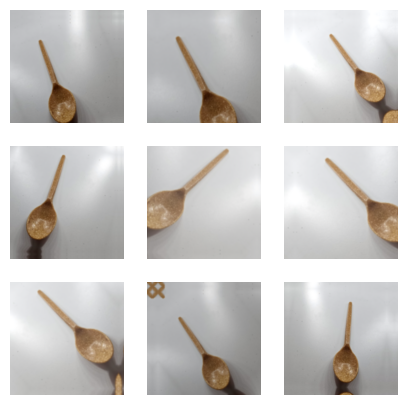

In [17]:
plt.figure(figsize=(5, 5))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

## CNN Model Architecture

The model is built using a sequential Convolutional Neural Network architecture.

The network consists of several convolutional layers followed by pooling layers to extract spatial features from the images.

### Architecture overview:

1. **Data Augmentation Layer** – applies random transformations to training images
2. **Rescaling Layer** – normalizes pixel values from the range [0,255] to [0,1]
3. **Convolutional Layers** – extract visual features from the images
4. **MaxPooling Layers** – reduce spatial dimensions and computational cost
5. **Dropout Layers** – help prevent overfitting
6. **GlobalAveragePooling Layer** – reduces feature maps before the classifier
7. **Dense Layer** – learns higher-level feature representations
8. **Softmax Output Layer** – outputs probabilities for the 5 classes

The model contains approximately **28,000 trainable parameters**, making it relatively lightweight and suitable for a small dataset.

In [18]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

## Model Training

The model is trained using the **Adam optimizer** and **categorical crossentropy loss**, which is suitable for multi-class classification problems.

To avoid overfitting, **Early Stopping** is used during training. Early stopping monitors the validation loss and stops training if the model stops improving.

Training parameters:
- Maximum epochs: 50
- Batch size: 32
- Early stopping patience: 5 epochs

During training, the model learns to recognize visual patterns that differentiate the five object categories.

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.build(input_shape=(None, 224, 224, 3))  # batch_size None
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 222, 222, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 111, 111, 16)      0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 111, 111, 16)      0         
                                                                 
 conv2d_4 (Conv2D)           (None, 109, 109, 32)      4640      
                                                      

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=[early_stop],
    verbose=0
)

## Model Evaluation

After training, the model is evaluated on the **test dataset**, which contains images the model has never seen before.

This provides an unbiased estimate of the model's real-world performance.

The evaluation reports:
- **Test loss**
- **Test accuracy**

In this experiment, the model achieved **70% test accuracy** on the test set, which is a solid result considering the small size of the dataset and visual similarity between some classes.

In [26]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.2f}")

2/2 [==============================] - 0s 3ms/step - loss: 0.7581 - accuracy: 0.7000
Test accuracy: 0.70


## Training Performance Visualization

To better understand the training process, we plot:

- **Training vs validation accuracy**
- **Training vs validation loss**

These curves help us analyze whether the model is:
- learning effectively
- overfitting
- underfitting

Ideally, the training and validation curves should improve together and stabilize as training progresses.

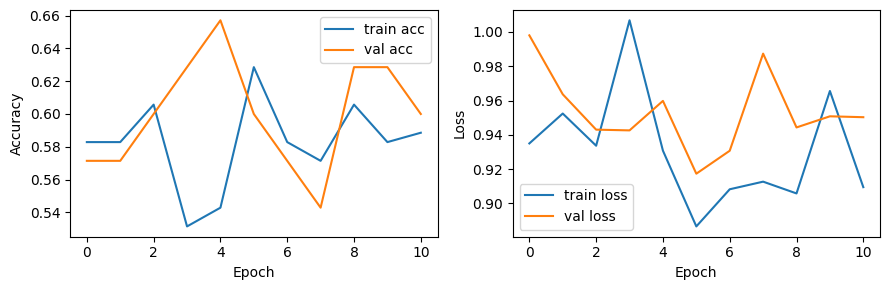

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

ax1.plot(history.history['accuracy'], label='train acc')
ax1.plot(history.history['val_accuracy'], label='val acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='val loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Prediction Analysis

To further analyze the model's performance, we visualize examples of:

- **Correctly classified images**
- **Incorrectly classified images**

This allows us to understand where the model performs well and where it struggles.

By inspecting the misclassified images, we can identify possible reasons for errors, such as:
- similar-looking objects
- unusual lighting conditions
- difficult viewing angles
- background distractions

This type of qualitative analysis is important for understanding model behavior beyond simple accuracy metrics.

1/1 [==============================] - 0s 18ms/step


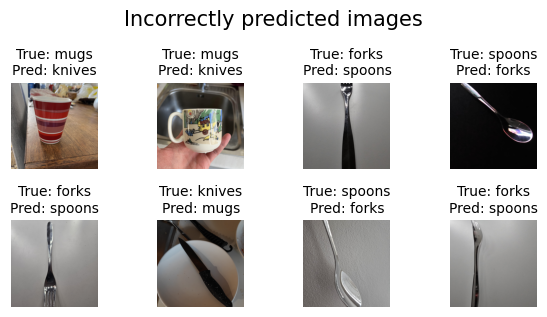

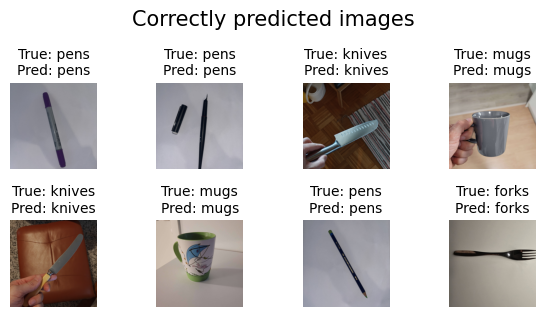

In [28]:
class_names = ['forks', 'knives', 'mugs', 'pens', 'spoons']

def collect_images(dataset, model):
    correct, wrong = [], []
    for images, labels in dataset.take(1):
        preds = model.predict(images)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = np.argmax(labels.numpy(), axis=1)
        for img, t, p in zip(images, true_labels, pred_labels):
            entry = (img.numpy().astype("uint8"), class_names[t], class_names[p])
            if t == p:
                correct.append(entry)
            else:
                wrong.append(entry)
    return correct, wrong

def plot_images(images_list, title, n=8):   # n = amount of images
    num = min(n, len(images_list))
    plt.figure(figsize=(6,6))
    for i in range(num):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images_list[i][0])
        plt.title(f"True: {images_list[i][1]}\nPred: {images_list[i][2]}", fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

correct_images, wrong_images = collect_images(test_dataset, model)

plot_images(wrong_images, "Incorrectly predicted images")
plot_images(correct_images, "Correctly predicted images")

## Summary

The custom CNN model achieved **70% test accuracy** on our own image dataset.

Data augmentation (flip, rotation, zoom, translation, brightness, and contrast changes) improved generalization by exposing the model to realistic variations in lighting, angle, and object position.

Overall, the model performs fairly well on our own images, but some confusion remains between visually similar classes. More data and class-specific examples would likely improve accuracy further.